# How to *Read* Data Visualizations
### CIS*4020 · organized by univariate / bivariate / multivariate

Choosing and reading a chart comes down to two questions:
1. **How many variables** are you looking at? (one → *univariate*, two → *bivariate*, three+ → *multivariate*)
2. **What type** is each variable? (nominal / ordinal / interval / ratio — or broadly *categorical* vs *numeric*)

For **every** chart below you get: a **definition** (what it shows), **how to read it**,
**which variable types** it suits, an example, and (where useful) an annotated version.

Runs with only `numpy`, `pandas`, `matplotlib`, `scikit-learn`.

## Setup & data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# ---- Iris: 4 continuous (ratio) features + species (nominal) -- great for MULTIVARIATE demos
iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={
    "sepal length (cm)":"sepal_length","sepal width (cm)":"sepal_width",
    "petal length (cm)":"petal_length","petal width (cm)":"petal_width"})
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)
FEAT = ["sepal_length","sepal_width","petal_length","petal_width"]
COLORS = {"setosa":"#2A6FB0","versicolor":"#2E7D6B","virginica":"#C44E52"}

# ---- A synthetic table with ALL four attribute types -- for categorical/typed demos
rng = np.random.default_rng(7); n = 600
edu_levels = ["High School","Bachelor","Master","PhD"]
edu_idx = rng.choice(4, n, p=[.35,.40,.20,.05])
age = rng.integers(22, 68, n)
base = 25000 + edu_idx*14000 + (age-22)*600
income = np.round(rng.lognormal(np.log(base), 0.25)).astype(int)     # right-skewed (ratio)
people = pd.DataFrame({
    "gender":       rng.choice(["F","M"], n),                                    # NOMINAL
    "region":       rng.choice(["North","South","East","West"], n),              # NOMINAL
    "education":    pd.Categorical([edu_levels[i] for i in edu_idx],
                                   categories=edu_levels, ordered=True),         # ORDINAL
    "satisfaction": np.clip(np.round(rng.normal(3 + edu_idx*0.25, 1)),1,5).astype(int),  # ORDINAL (1-5)
    "signup_year":  rng.integers(2016, 2024, n),                                 # INTERVAL
    "age":          age,                                                         # RATIO
    "income":       income,                                                      # RATIO
    "num_purchases":rng.poisson(np.clip(income/20000,1,None)).astype(int),       # RATIO (discrete count)
})
people.head()

,gender,region,education,satisfaction,signup_year,age,income,num_purchases
0,F,North,Bachelor,5,2020,55,57189,1
1,M,South,Master,2,2018,61,85716,4
2,F,South,Master,5,2022,65,94909,4
3,F,South,High School,4,2019,56,40698,3
4,M,East,High School,3,2018,26,29588,4


## Variable types → chart choice  *(read this first)*

| Type | Example here | Treat as | Typical charts |
|---|---|---|---|
| **Nominal** | `gender`, `region` | categorical (unordered) | bar / count plot |
| **Ordinal** | `education`, `satisfaction` | categorical (ordered) | *ordered* bar; box vs a numeric |
| **Interval** | `signup_year` | numeric (no true zero) | histogram, line, scatter |
| **Ratio** | `age`, `income`, `num_purchases` | numeric (true zero) | histogram, box, scatter |

Two broader buckets you'll hear: **discrete** (few distinct values — counts, categories) vs
**continuous** (infinitely divisible — height, income). Discrete-with-few-values → treat like
categorical (bar); continuous or discrete-with-many-values → treat like numeric (histogram/box).

**Chart-selection cheat table**

| # of variables | Variable types | Good charts |
|---|---|---|
| 1 | categorical | bar / count plot |
| 1 | numeric | histogram, box plot, density |
| 2 | numeric × numeric | scatter (line if x is ordered/time) |
| 2 | categorical × numeric | box / violin by group, bar of group means |
| 2 | categorical × categorical | grouped / stacked bar, contingency heatmap |
| 3+ | several numeric (+ a class) | scatter matrix, correlation heatmap, parallel coordinates, data matrix |
| 3 | 2 numeric + 1 categorical | colour / size / facet a scatter |

# Part A — Univariate: one variable at a time

Univariate charts describe the **distribution of a single variable**: what values occur and how often.

### A1. Bar / count plot  *(categorical variable)*
- **Shows:** how many observations fall in each category (one bar per category).
- **How to read:** compare bar heights = counts (or proportions). For **ordinal** data keep the
  bars in their natural order so the trend is readable; for **nominal** data the order is arbitrary
  (often sort by height).
- **Appropriate for:** one **nominal** or **ordinal** variable (or any discrete variable with few values).

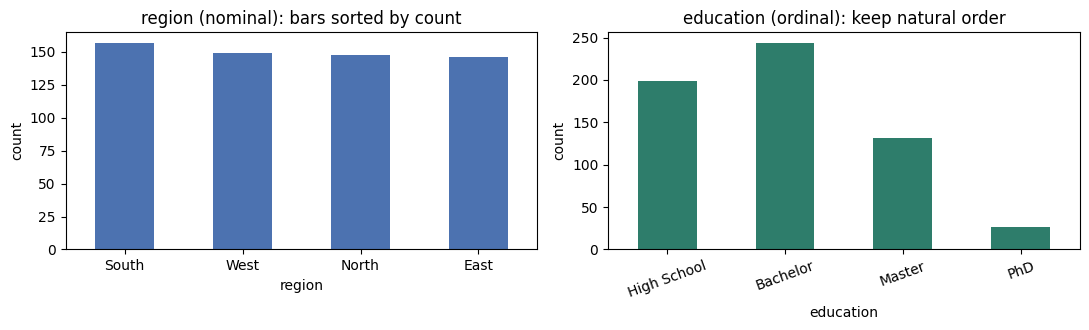

Reading: heights are counts. For ordinal data the LEFT-TO-RIGHT order carries meaning.


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.4))
# NOMINAL: order doesn't matter -> sort by height for readability
people["region"].value_counts().plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("region (nominal): bars sorted by count"); ax[0].set_ylabel("count"); ax[0].tick_params(axis="x", rotation=0)
# ORDINAL: KEEP the natural order (High School -> PhD)
people["education"].value_counts()[edu_levels].plot(kind="bar", ax=ax[1], color="#2E7D6B")
ax[1].set_title("education (ordinal): keep natural order"); ax[1].set_ylabel("count"); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
print("Reading: heights are counts. For ordinal data the LEFT-TO-RIGHT order carries meaning.")

*Pie charts* also show category shares, but humans compare angles poorly — a bar chart is
almost always easier to read. Prefer bars.

### A2. Histogram  *(numeric variable)*
- **Shows:** the distribution of one numeric variable — values are grouped into **bins** and each
  bar's height is the count in that bin.
- **How to read:** look at **centre**, **spread**, **shape** (symmetric / skewed / one hump or several),
  and gaps/outliers. A long tail on one side = skew (the mean gets pulled toward the tail).
- **Appropriate for:** one **interval** or **ratio** variable (continuous, or discrete with many values).

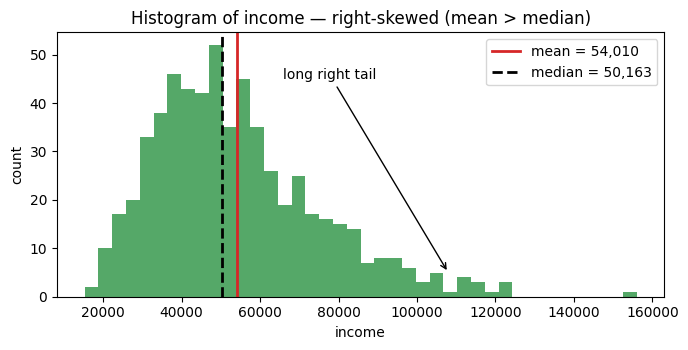

In [5]:
plt.figure(figsize=(7,3.6))
plt.hist(people["income"], bins=40, color="#55A868")
plt.axvline(people["income"].mean(),   color="C3", lw=2, label=f"mean = {people['income'].mean():,.0f}")
plt.axvline(people["income"].median(), color="k",  lw=2, ls="--", label=f"median = {people['income'].median():,.0f}")
plt.annotate("long right tail", xy=(people["income"].quantile(0.98), 5),
             xytext=(people["income"].quantile(0.75), 45), arrowprops=dict(arrowstyle="->"), fontsize=10)
plt.legend(); plt.xlabel("income"); plt.ylabel("count")
plt.title("Histogram of income — right-skewed (mean > median)")
plt.tight_layout(); plt.show()

**Watch out:** the number of **bins** changes the apparent shape — too few hides structure, too
many looks noisy. Try a couple of bin counts before drawing conclusions.

### A3. Box plot  *(numeric variable)*
- **Shows:** a five-number summary — median, quartiles (Q1, Q3), "whiskers", and outliers.
- **How to read:** the line is the **median**; the box is the **middle 50%** (IQR); whiskers reach
  most of the range; dots beyond them are **outliers** (~1.5·IQR rule).
- **Appropriate for:** one **interval/ratio** variable. Especially good for **comparing groups** (Part B).
- **Watch out:** a box plot can look ordinary even when the data is **bimodal** — pair it with a histogram.

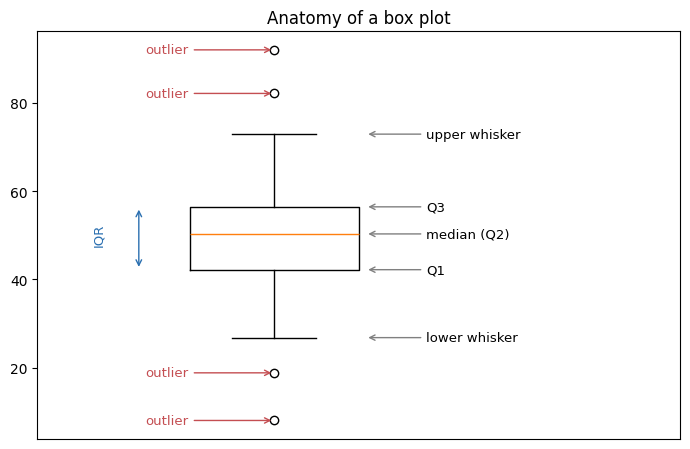

In [6]:
# Annotated anatomy of a box plot
x = np.concatenate([rng.normal(50, 10, 200), [92, 8]])
q1, med, q3 = np.percentile(x, [25, 50, 75]); iqr = q3 - q1
lo = x[x >= q1 - 1.5*iqr].min(); hi = x[x <= q3 + 1.5*iqr].max()
fig, ax = plt.subplots(figsize=(7,4.6)); ax.boxplot(x, widths=0.5)
for val, lab in [(med,"median (Q2)"),(q1,"Q1"),(q3,"Q3"),(lo,"lower whisker"),(hi,"upper whisker")]:
    ax.annotate(lab, xy=(1.27,val), xytext=(1.45,val), va="center", fontsize=9.5,
                arrowprops=dict(arrowstyle="->", color="gray"))
ax.annotate("", xy=(0.60,q1), xytext=(0.60,q3), arrowprops=dict(arrowstyle="<->", color="#2A6FB0"))
ax.text(0.50, med, "IQR", rotation=90, va="center", ha="right", color="#2A6FB0", fontsize=9.5)
for o in x[(x<lo)|(x>hi)]:
    ax.annotate("outlier", xy=(1.0,o), xytext=(0.62,o), va="center", color="#C44E52", fontsize=9.5,
                arrowprops=dict(arrowstyle="->", color="#C44E52"))
ax.set_xlim(0.3,2.2); ax.set_xticks([]); ax.set_title("Anatomy of a box plot")
plt.tight_layout(); plt.show()

# Part B — Bivariate: two variables (a relationship)

Bivariate charts show how **two variables relate**. The right chart depends on the **type combination**:

| Pair of types | Chart |
|---|---|
| numeric × numeric | scatter plot |
| categorical × numeric | box / violin by group |
| categorical × categorical | grouped bar or contingency heatmap |

### B1. Scatter plot  *(numeric × numeric)*
- **Shows:** each object as a point positioned by two numeric variables.
- **How to read:** the **trend** (up / down / none), its **strength** (tight line vs cloud),
  **clusters**, **outliers**, and whether it's straight or **curved**.
- **Appropriate for:** two **interval/ratio** variables. (If one axis is time/ordered, use a **line plot**.)

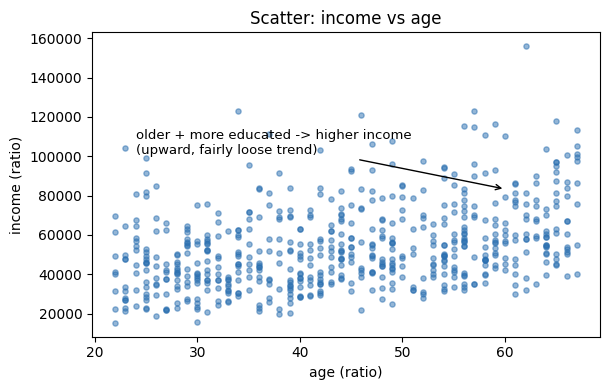

Reading: direction (up), strength (loose cloud), any outliers? For many points, use alpha to see density.


In [7]:
plt.figure(figsize=(6.2,4))
plt.scatter(people["age"], people["income"], s=14, alpha=0.5, color="#2A6FB0")
plt.annotate("older + more educated -> higher income\n(upward, fairly loose trend)",
             xy=(60, people["income"].quantile(0.9)), xytext=(24, people["income"].quantile(0.97)),
             arrowprops=dict(arrowstyle="->"), fontsize=9.5)
plt.xlabel("age (ratio)"); plt.ylabel("income (ratio)")
plt.title("Scatter: income vs age"); plt.tight_layout(); plt.show()
print("Reading: direction (up), strength (loose cloud), any outliers? For many points, use alpha to see density.")

### B2. Box plots by group  *(categorical × numeric)*
- **Shows:** the distribution of a numeric variable **within each category** of a grouping variable.
- **How to read:** compare medians (the lines), box heights (spread), and outliers **across groups**;
  a rising staircase of medians signals a relationship.
- **Appropriate for:** one **categorical** variable (nominal or ordinal) × one **numeric** variable.
  Keep the boxes in category order for ordinal groups.

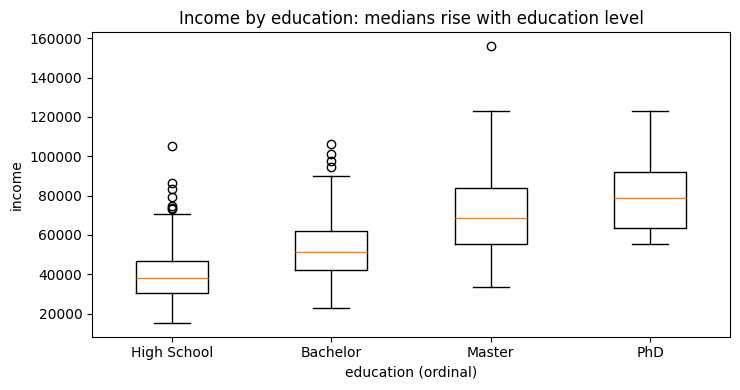

Reading: the medians step upward left-to-right -> higher education is associated with higher income.


In [8]:
groups = [people.loc[people["education"]==lvl, "income"] for lvl in edu_levels]
fig, ax = plt.subplots(figsize=(7.5,4))
ax.boxplot(groups, tick_labels=edu_levels, showfliers=True)
ax.set_ylabel("income"); ax.set_xlabel("education (ordinal)")
ax.set_title("Income by education: medians rise with education level")
plt.tight_layout(); plt.show()
print("Reading: the medians step upward left-to-right -> higher education is associated with higher income.")

### B3. Contingency heatmap  *(categorical × categorical)*
- **Shows:** how two categorical variables co-occur — a table of counts (or proportions) shown as colour.
- **How to read:** brighter/darker cells = more common combinations. Normalizing by row lets you compare
  the *profile* of each row category. Look for cells that stand out from a uniform pattern.
- **Appropriate for:** two **categorical** variables (nominal or ordinal). A **grouped/stacked bar** works too.

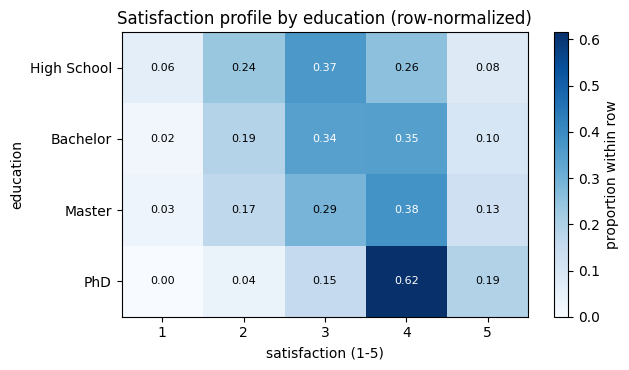

Reading: within each education row, where does the colour concentrate? Higher education leans to higher satisfaction.


In [9]:
ct = pd.crosstab(people["education"], people["satisfaction"], normalize="index")  # row = education
fig, ax = plt.subplots(figsize=(6.5,3.8))
im = ax.imshow(ct.values, cmap="Blues", aspect="auto"); fig.colorbar(im, label="proportion within row")
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns); ax.set_xlabel("satisfaction (1-5)")
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index);  ax.set_ylabel("education")
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, f"{ct.values[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if ct.values[i,j] > 0.3 else "black")
ax.set_title("Satisfaction profile by education (row-normalized)")
plt.tight_layout(); plt.show()
print("Reading: within each education row, where does the colour concentrate? Higher education leans to higher satisfaction.")

# Part C — Multivariate: three or more variables

Multivariate charts pack several variables into one view. They're powerful but denser to read —
take them one element at a time.

### C1. Coloured scatter  *(2 numeric + 1 categorical)*
- **Shows:** a scatter of two numeric variables, with a **third categorical** variable mapped to colour.
- **How to read:** as a scatter, but now check whether the **colour groups occupy different regions**
  (i.e., the categories separate in this 2-D view).
- **Appropriate for:** two numeric + one categorical. (Add a 4th via marker **size** = a bubble chart.)

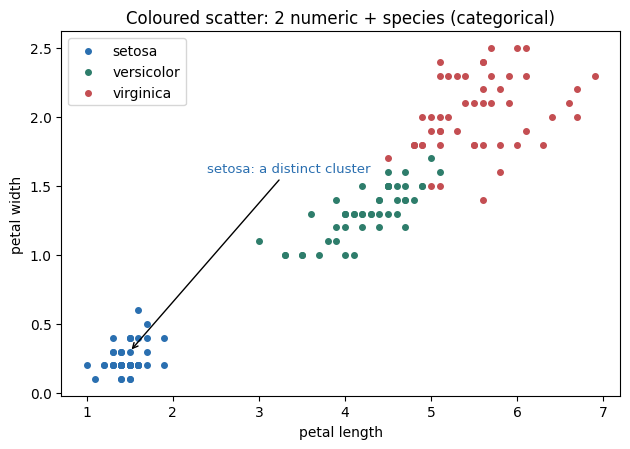

In [10]:
plt.figure(figsize=(6.4,4.6))
for s in df.species.cat.categories:
    sub = df[df.species==s]
    plt.scatter(sub["petal_length"], sub["petal_width"], s=16, color=COLORS[s], label=s)
plt.annotate("setosa: a distinct cluster", xy=(1.5,0.3), xytext=(2.4,1.6),
             arrowprops=dict(arrowstyle="->"), fontsize=9.5, color="#2A6FB0")
plt.xlabel("petal length"); plt.ylabel("petal width"); plt.legend()
plt.title("Coloured scatter: 2 numeric + species (categorical)")
plt.tight_layout(); plt.show()

### C2. Scatter-plot matrix  *(several numeric, optional class colour)*
- **Shows:** every pair of numeric variables as a small scatter, arranged in a grid (diagonals show each
  variable's own distribution).
- **How to read:** scan for the panel with the **clearest structure** — the pair that best separates
  groups or shows the strongest relationship.
- **Appropriate for:** several **numeric** variables; colour by a class to check separability.

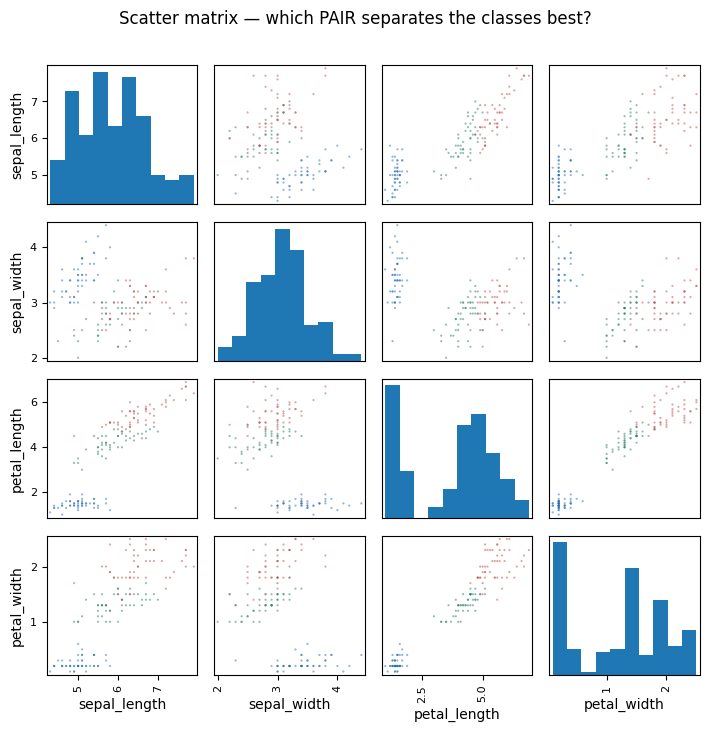

In [11]:
from pandas.plotting import scatter_matrix
scatter_matrix(df[FEAT], c=df.species.map(COLORS), figsize=(7.2,7.2), diagonal="hist", s=10)
plt.suptitle("Scatter matrix — which PAIR separates the classes best?", y=1.01)
plt.tight_layout(); plt.show()

### C3. Correlation heatmap  *(several numeric)*
- **Shows:** the pairwise linear correlation between numeric variables as a colour grid (−1 to +1).
- **How to read:** strong reds/blues (near ±1) = tightly related pairs; near 0 = little linear relation.
  Redundant (highly correlated) features show up as bright off-diagonal cells.
- **Appropriate for:** several **numeric** (interval/ratio) variables.

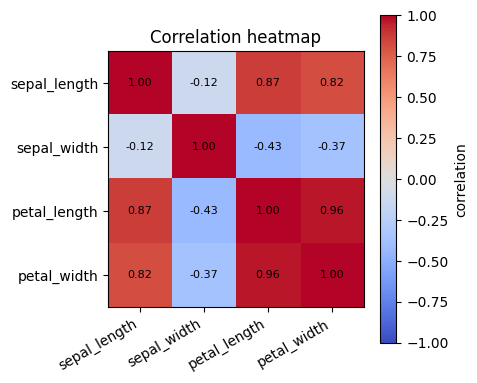

In [12]:
corr = df[FEAT].corr()
fig, ax = plt.subplots(figsize=(4.8,4.2))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1); fig.colorbar(im, label="correlation")
ax.set_xticks(range(4)); ax.set_xticklabels(FEAT, rotation=30, ha="right"); ax.set_yticks(range(4)); ax.set_yticklabels(FEAT)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlation heatmap"); plt.tight_layout(); plt.show()

### C4. Data matrix  *(objects × attributes, as a heatmap)*
- **Shows:** the whole table as colour — rows = objects (sorted by class), columns = attributes,
  colour = value (standardize first so one wide-range column doesn't dominate).
- **How to read:** horizontal **colour bands** = groups of similar objects; columns whose colour
  **flips sharply** between bands are the attributes that distinguish the groups.
- **Appropriate for:** many objects × several **numeric** attributes.

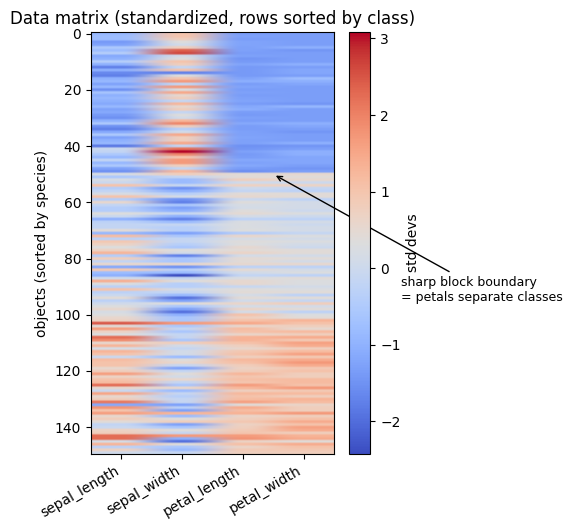

In [13]:
Z = (df[FEAT] - df[FEAT].mean()) / df[FEAT].std()
Z = Z.iloc[np.argsort(df.species.cat.codes.values)]
fig, ax = plt.subplots(figsize=(5.6,5.4))
im = ax.imshow(Z.values, aspect="auto", cmap="coolwarm"); fig.colorbar(im, label="std devs")
ax.set_xticks(range(4)); ax.set_xticklabels(FEAT, rotation=30, ha="right")
ax.set_ylabel("objects (sorted by species)")
ax.annotate("sharp block boundary\n= petals separate classes", xy=(2.5,50), xytext=(4.6,95),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.set_title("Data matrix (standardized, rows sorted by class)"); plt.tight_layout(); plt.show()

### C5. Parallel coordinates  *(several numeric + a class)*
- **Shows:** each object as a **line** crossing one parallel vertical axis per variable.
- **How to read:** follow one colour at a time; where its lines **bundle tightly** on an axis, that
  variable separates the class; where colours **overlap/cross**, it doesn't.
- **Appropriate for:** several **numeric** variables + a class label. **Axis order matters** — put
  related axes next to each other; put variables on comparable scales.

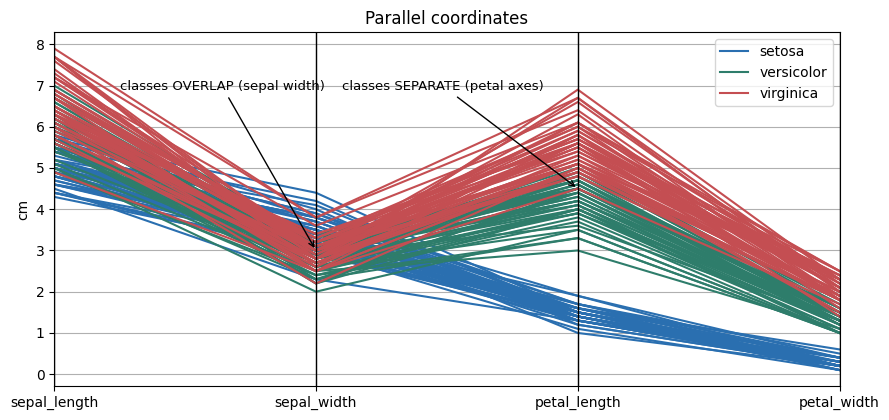

In [18]:
from pandas.plotting import parallel_coordinates
plt.figure(figsize=(9,4.3))
parallel_coordinates(df[FEAT+["species"]], "species", color=[COLORS[s] for s in df.species.cat.categories])
plt.annotate("classes SEPARATE (petal axes)", xy=(2.0,4.5), xytext=(1.1,6.9), arrowprops=dict(arrowstyle="->"), fontsize=9.5)
plt.annotate("classes OVERLAP (sepal width)", xy=(1.0,3.0), xytext=(0.25,6.9), arrowprops=dict(arrowstyle="->"), fontsize=9.5)
plt.ylabel("cm"); plt.title("Parallel coordinates"); plt.tight_layout(); plt.show()

# A reading checklist (works for any chart)

1. **How many variables, and what type is each?** (that picks the chart)
2. **What's on each axis / element?** (units; what a point/bar/line/cell represents)
3. **Centre & spread**, then **shape** (symmetric / skewed / one hump or several).
4. **Groups / clusters** — do points or rows fall into distinct blocks?
5. **Relationship** — for two variables, direction and strength.
6. **Outliers** — anything far from the rest, and is it an error or real?
7. **What could mislead me?** — bins, scales, overplotting, axis order, sorted-away ordinal order.

**Quick chooser:** *1 variable* → bar (categorical) / histogram + box (numeric) · *2 variables* →
scatter (num×num), box-by-group (cat×num), heatmap or grouped bar (cat×cat) · *3+ variables* →
coloured scatter, scatter matrix, correlation heatmap, data matrix, parallel coordinates.